In [51]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/adhurimquku/ford-car-price-prediction/ford.csv


In [52]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [53]:
df = pd.read_csv(r'/kaggle/input/datasets/adhurimquku/ford-car-price-prediction/ford.csv')

In [54]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [55]:
df.shape

(17966, 9)

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [57]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [58]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [59]:
df.duplicated().sum()

np.int64(154)

In [60]:
df.drop_duplicates(inplace=True)

In [61]:
df.duplicated().sum()

np.int64(0)

# EDA

<Axes: xlabel='price', ylabel='Count'>

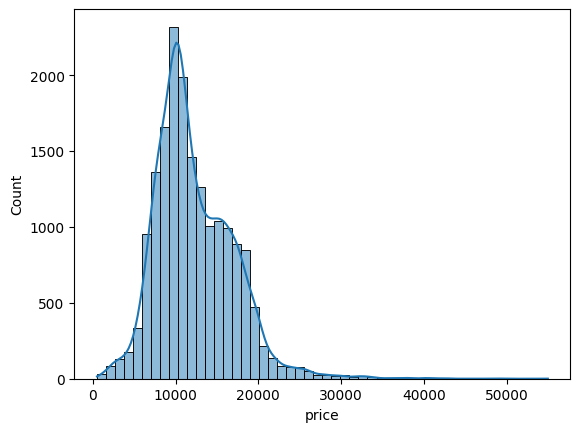

In [62]:
sns.histplot(df['price'],kde=True, bins=50)

In [63]:
df.corr(numeric_only = True)

,year,price,mileage,tax,mpg,engineSize
year,1.000000,0.635715,-0.708690,0.297183,-0.021702,-0.137582
price,0.635715,1.000000,-0.530483,0.405969,-0.346263,0.411451
mileage,-0.708690,-0.530483,1.000000,-0.257543,0.117697,0.214692
tax,0.297183,0.405969,-0.257543,1.000000,-0.502343,0.185358
mpg,-0.021702,-0.346263,0.117697,-0.502343,1.000000,-0.262239
engineSize,-0.137582,0.411451,0.214692,0.185358,-0.262239,1.000000


<Axes: >

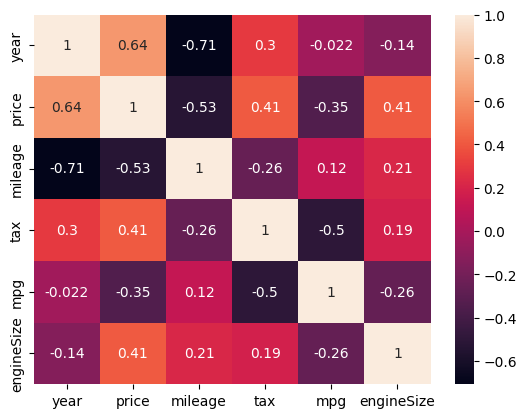

In [64]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

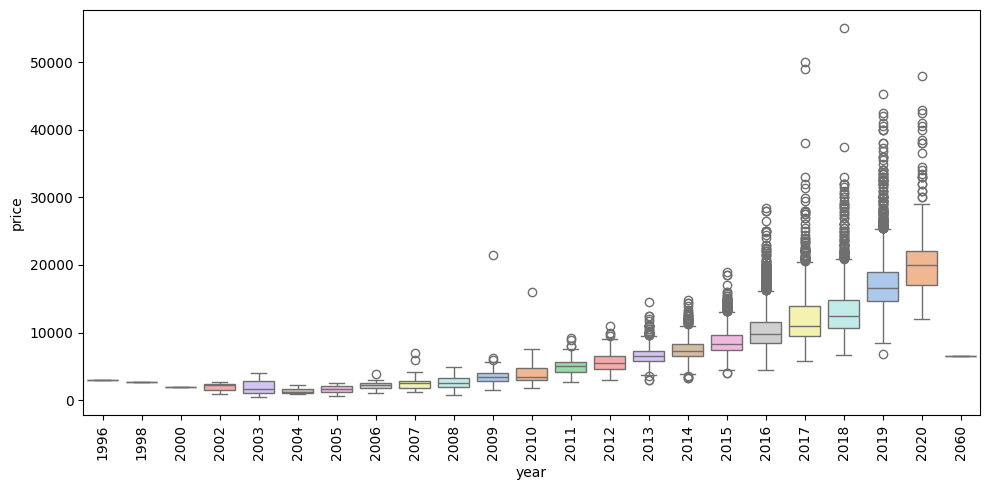

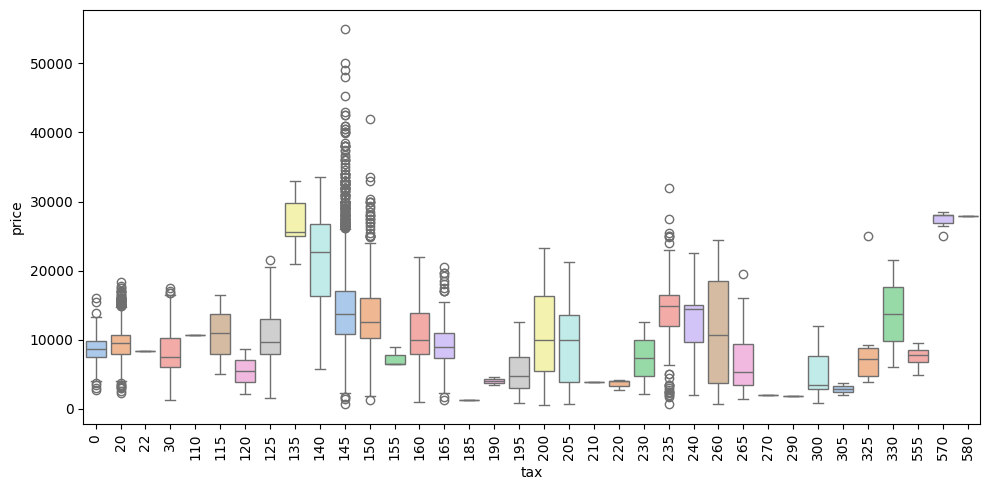

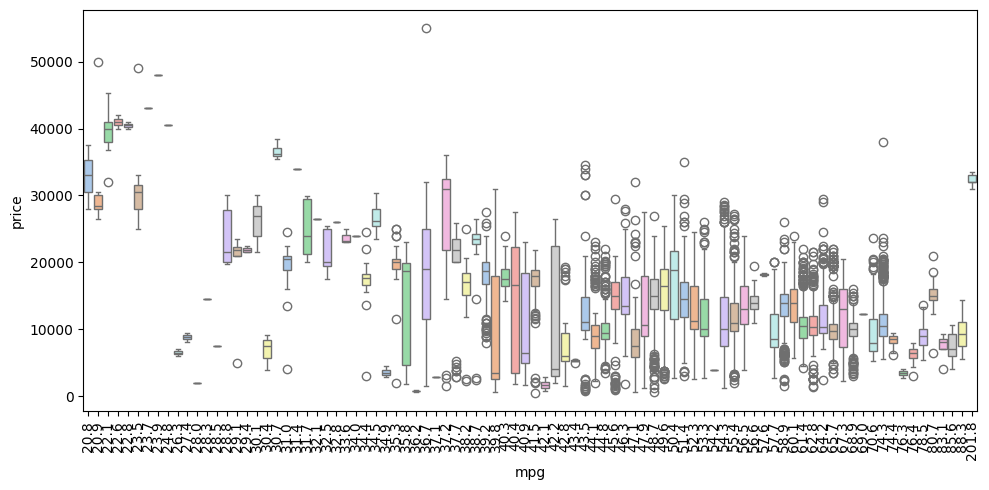

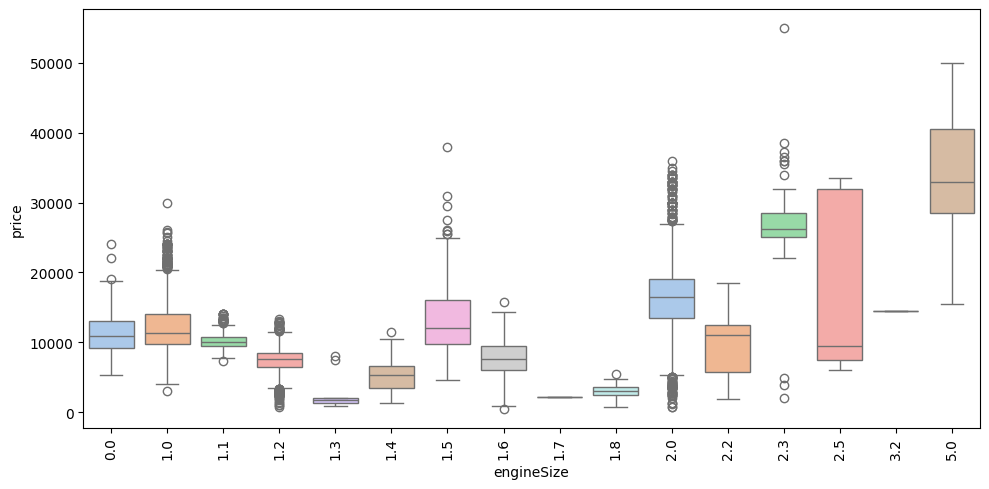

In [65]:
def boxplots(var):
    plt.figure(figsize=(10,5))
    sns.boxplot(data=df, x = df[var], y = df['price'], palette='pastel')
    plt.xticks(rotation = 90)
    plt.tight_layout()
    plt.show()

cols = ['year', 'tax', 'mpg', 'engineSize']

for col in cols:
    boxplots(col)


<Axes: xlabel='price', ylabel='mpg'>

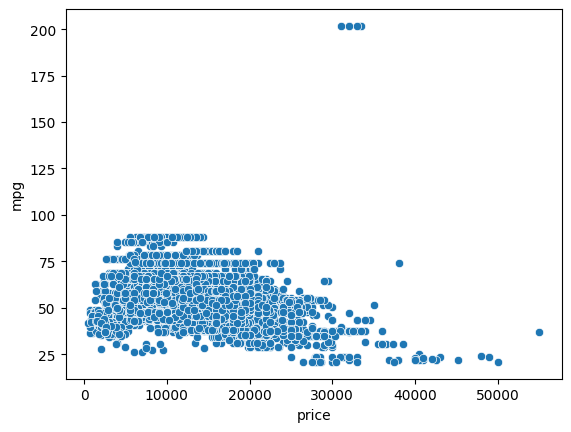

In [66]:
sns.scatterplot(data=df, x = df['price'], y = df['mpg'])

<Axes: xlabel='transmission', ylabel='price'>

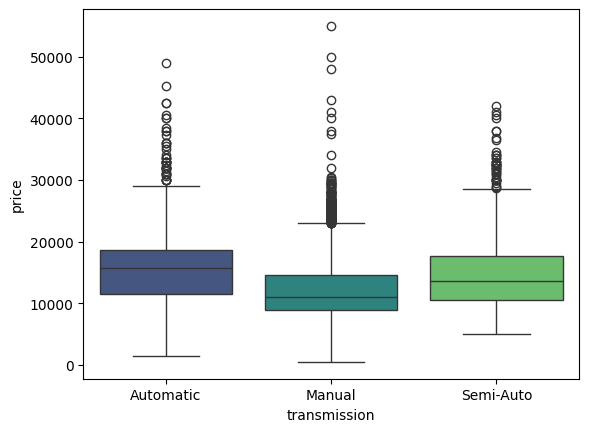

In [67]:
sns.boxplot(data=df, x=df['transmission'], y=df['price'], palette='viridis')

We can use transmission, however as you can see that they are all kind of in a same range

<Axes: xlabel='fuelType', ylabel='price'>

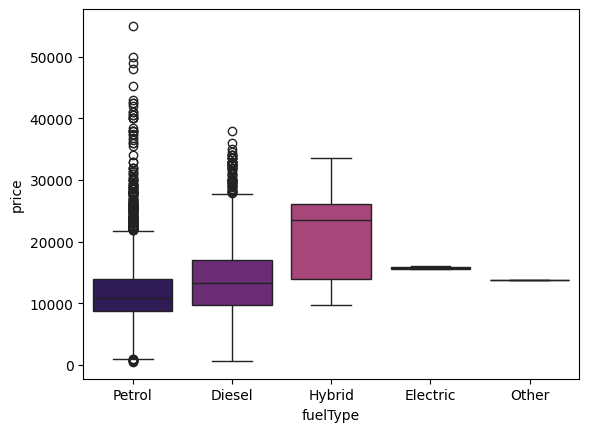

In [68]:
sns.boxplot(data=df, x = df['fuelType'], y = df['price'], palette='magma')

Here, you can see that petrol has some really high prices, so we can def use fuelTypes

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23],
 [Text(0, 0, ' Fiesta'),
  Text(1, 0, ' Focus'),
  Text(2, 0, ' Puma'),
  Text(3, 0, ' Kuga'),
  Text(4, 0, ' EcoSport'),
  Text(5, 0, ' C-MAX'),
  Text(6, 0, ' Mondeo'),
  Text(7, 0, ' Ka+'),
  Text(8, 0, ' Tourneo Custom'),
  Text(9, 0, ' S-MAX'),
  Text(10, 0, ' B-MAX'),
  Text(11, 0, ' Edge'),
  Text(12, 0, ' Tourneo Connect'),
  Text(13, 0, ' Grand C-MAX'),
  Text(14, 0, ' KA'),
  Text(15, 0, ' Galaxy'),
  Text(16, 0, ' Mustang'),
  Text(17, 0, ' Grand Tourneo Connect'),
  Text(18, 0, ' Fusion'),
  Text(19, 0, ' Ranger'),
  Text(20, 0, ' Streetka'),
  Text(21, 0, ' Escort'),
  Text(22, 0, ' Transit Tourneo'),
  Text(23, 0, 'Focus')])

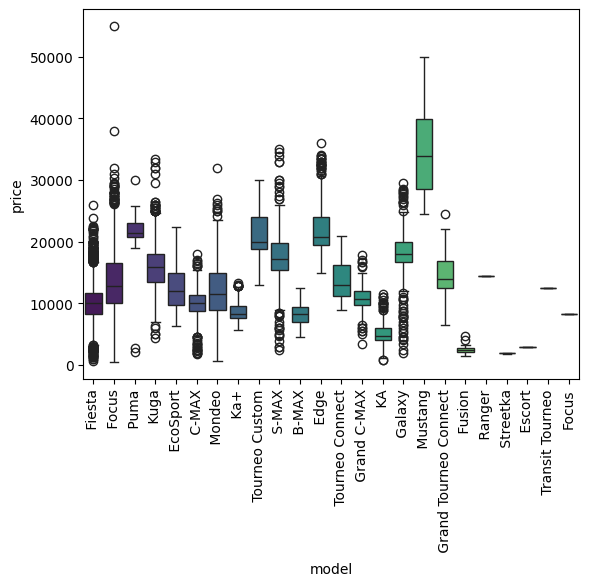

In [69]:
sns.boxplot(data=df, x=df['model'], y=df['price'], palette = 'viridis')
plt.xticks(rotation = 90)

In [70]:
X = df.drop(columns=['price'], axis=1)
y = df['price']

In [71]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

In [72]:
X_one_encode = pd.get_dummies(X, columns = ['model', 'transmission', 'fuelType'], drop_first=True)
X_one_encode.head()

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57.7,1.0,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
1,2018,9083,150,57.7,1.0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,2017,12456,150,57.7,1.0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
3,2019,10460,145,40.3,1.5,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,True
4,2019,1482,145,48.7,1.0,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True


In [73]:
X_one_encode = X_one_encode.astype(int)
X_one_encode.head()

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,2017,15944,150,57,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,2018,9083,150,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,2017,12456,150,57,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,2019,10460,145,40,1,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,2019,1482,145,48,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1


In [74]:
from sklearn.preprocessing import LabelEncoder
encode = LabelEncoder()
columns = ['model', 'transmission', 'fuelType']
Xlabel_encode = X.copy()

for i in columns:
    Xlabel_encode[i] = encode.fit_transform(Xlabel_encode[i])

Xlabel_encode.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,0,15944,4,150,57.7,1.0
1,6,2018,1,9083,4,150,57.7,1.0
2,6,2017,1,12456,4,150,57.7,1.0
3,5,2019,1,10460,4,145,40.3,1.5
4,5,2019,0,1482,4,145,48.7,1.0


In [77]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

numeric_cols = ['year', 'mpg', 'mileage', 'tax', 'engineSize']
X_one_encode[numeric_cols] = scaler.fit_transform(X_one_encode[numeric_cols])

X_one_encode.head()

,year,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,model_ Fiesta,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,transmission_Manual,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol
0,0.067059,-0.382994,0.591380,-0.042291,-0.446958,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1
1,0.554393,-0.736317,0.591380,-0.042291,-0.446958,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0.067059,-0.562616,0.591380,-0.042291,-0.446958,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,1.041726,-0.665405,0.510777,-1.720193,-0.446958,0,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
4,1.041726,-1.127749,0.510777,-0.930592,-0.446958,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1


In [78]:
Xlabel_encode[['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize']] = scaler.fit_transform(Xlabel_encode[['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize']])

Xlabel_encode.head()

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,-0.460281,0.067059,-2.667947,-0.382994,0.688206,0.591380,-0.020597,-0.810561
1,-0.210828,0.554393,0.042455,-0.736317,0.688206,0.591380,-0.020597,-0.810561
2,-0.210828,0.067059,0.042455,-0.562616,0.688206,0.591380,-0.020597,-0.810561
3,-0.460281,1.041726,0.042455,-0.665405,0.688206,0.510777,-1.737858,0.345325
4,-0.460281,1.041726,-2.667947,-1.127749,0.688206,0.510777,-0.908836,-0.810561


In [79]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [80]:
model = LinearRegression()

In [81]:
X_train, X_test, y_train, y_test = train_test_split(X_one_encode, y, test_size=0.2, random_state = 42)

In [82]:
model.fit(X_train,y_train)

LinearRegression()

In [83]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"R2_Score: ", r2)

R2_Score:  0.8256860539909145


In [84]:
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)
print("Adjusted R2 Score: ", adjusted_r2)

Adjusted R2 Score:  0.8240061576858383


In [85]:
mae = mean_absolute_error(y_pred, y_test)
mse = mean_squared_error(y_pred, y_test)

# Training Model 2 of Label Encoder

In [86]:
X_train_lb, X_test_lb, y_train_lb, y_test_lb = train_test_split(Xlabel_encode, y, test_size=0.2, random_state = 42)

In [87]:
model2 = LinearRegression()

In [88]:
model2.fit(X_train_lb, y_train_lb)

LinearRegression()

In [89]:
y_pred_lb = model2.predict(X_test_lb)

r2_lb = r2_score(y_test_lb, y_pred_lb)
print("R2 Score of Label Encoder Model: ", r2_lb)

R2 Score of Label Encoder Model:  0.7056898090851006


In [90]:
n = X_test_lb.shape[0]
p = X_test_lb.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)
print("Adjusted R2 Score of Label Encoder: ", adjusted_r2)

Adjusted R2 Score of Label Encoder:  0.8252936759469999
